Setup cell — imports, load data, load world geometries
Map 1 — yield choropleth
Map 2 — economic impact bubbles
Map 3 — temperature zones
4 — write to PostGIS + verify

In [9]:
#in this part we are finding out about our dataset
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))


DATA_PATH = Path("..//data/climate_change_impact_on_agriculture_2024.csv")
df = pd.read_csv(DATA_PATH)
df["Decade"] = (df["Year"] // 10) * 10
df["Country"] = df["Country"].replace("USA", "United States of America")


url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)


world = world[["ADMIN", "CONTINENT", "POP_EST", "geometry"]].copy()

print(f"World shape: {world.shape}")
print(f"DAtaset shape: {df.shape}")
print(f"Countries in dataset: {sorted(df['Country'].unique())}")
print(f"World CRS: {world.crs}")

World shape: (177, 4)
DAtaset shape: (10000, 16)
Countries in dataset: ['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France', 'India', 'Nigeria', 'Russia', 'United States of America']
World CRS: EPSG:4326


Map 1 - Grouping countries by average yield and making a map visualization

Average yield by country:
                      ADMIN  avg_yield
8                    Russia      2.204
5                    France      2.221
3                    Canada      2.229
2                    Brazil      2.231
1                 Australia      2.233
9  United States of America      2.238
0                 Argentina      2.250
6                     India      2.250
4                     China      2.260
7                   Nigeria      2.279


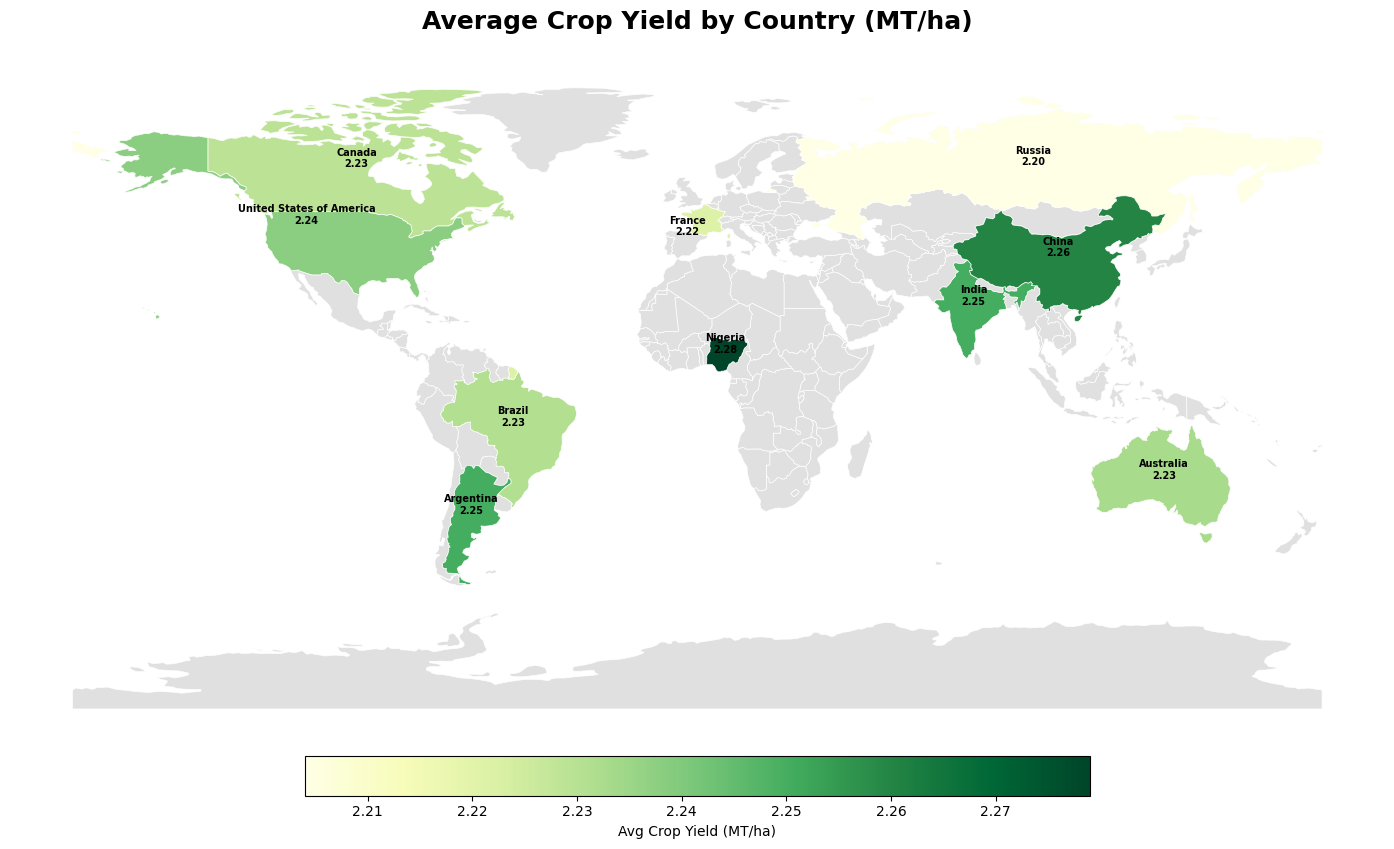

In [10]:
#grouping countries by average yield and making a map visualization
avg_yield = df.groupby("Country")["Crop_Yield_MT_per_HA"]\
    .mean()\
    .round(3)\
    .reset_index()\
    .rename(columns={"Crop_Yield_MT_per_HA": "avg_yield", "Country": "ADMIN"})
    
print("Average yield by country:")
print(avg_yield.sort_values("avg_yield", ascending=True))

world_yield = world.merge(avg_yield, on="ADMIN", how="left")

fig, ax = plt.subplots(figsize=(16, 9))

world.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.5)

world_yield.dropna(subset=["avg_yield"]).plot(
    ax      = ax,
    column  = "avg_yield",
    cmap    = "YlGn",
    legend  = True,
    edgecolor= "White",
    linewidth= 0.5,
    legend_kwds= {"label": "Avg Crop Yield (MT/ha)",
                "orientation": "horizontal",
                "shrink": 0.5,
                "pad": 0.02}
)

for idx, row in world_yield.dropna(subset=["avg_yield"]).iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['ADMIN']}\n{row['avg_yield']:.2f}",
        xy  = (centroid.x, centroid.y),
        ha  = "center",
        fontsize = 7,
        fontweight = "bold",
        color   = "black"
    )

ax.set_title("Average Crop Yield by Country (MT/ha)",
            fontsize=18, fontweight="bold", pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/maps/01_yield_choropleth.png", dpi=150)
plt.show()

Map 2 -Grouping by economys impact and making map for it

C:\Users\User\AppData\Local\Temp\ipykernel_13280\2716119710.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_econ_data["centroid_x"] = world_econ_data.geometry.centroid.x
C:\Users\User\AppData\Local\Temp\ipykernel_13280\2716119710.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_econ_data["centroid_y"] = world_econ_data.geometry.centroid.y


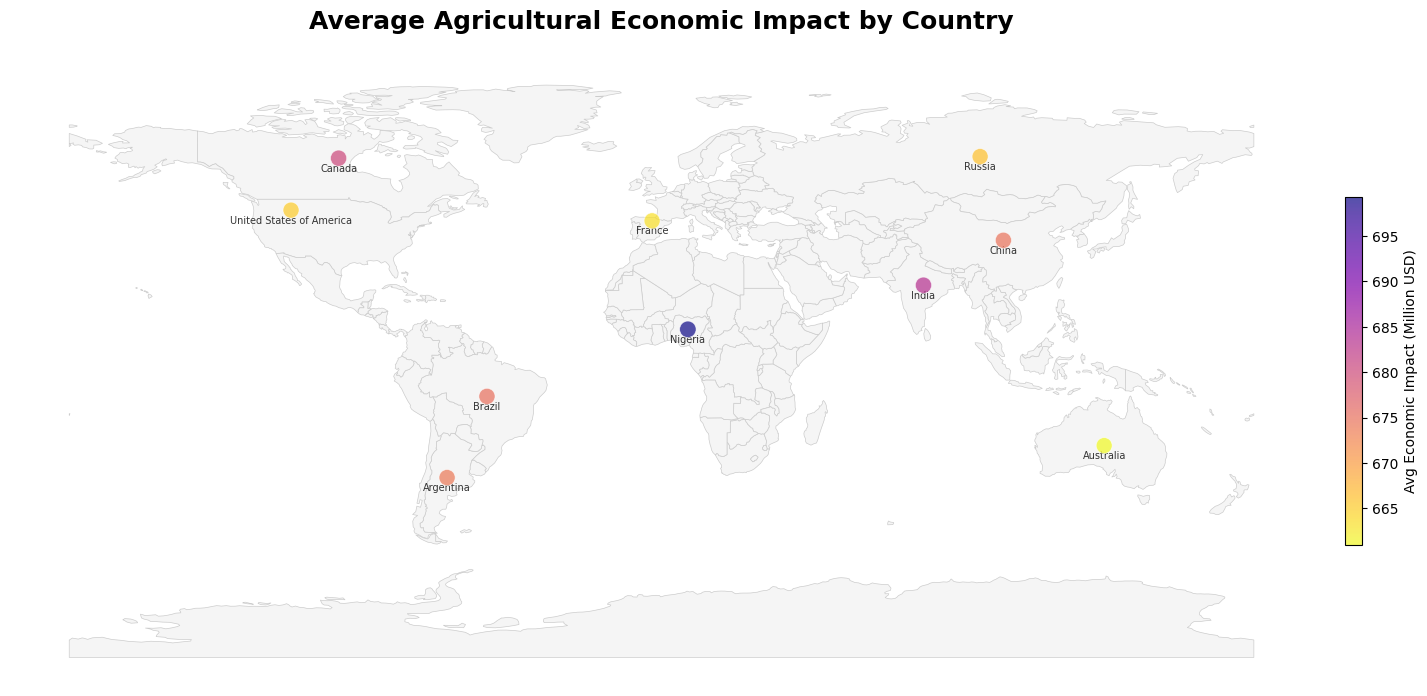

In [11]:
#grouping by economys impact and making map for it
econ_impact = df.groupby("Country")["Economic_Impact_Million_USD"]\
                .mean()\
                .round(2)\
                .reset_index()\
                .rename(columns={"Economic_Impact_Million_USD": "avg_econ", "Country": "ADMIN"})

world_econ = world.merge(econ_impact, on="ADMIN", how="left")

world_econ_data = world_econ.dropna(subset=["avg_econ"]).copy()
world_econ_data["centroid_x"] = world_econ_data.geometry.centroid.x
world_econ_data["centroid_y"] = world_econ_data.geometry.centroid.y

fig, ax = plt.subplots(figsize=(16, 9))

world.plot(ax=ax, color="#f5f5f5", edgecolor="#cccccc", linewidth=0.5)

scatter = ax.scatter(
    x   = world_econ_data["centroid_x"],
    y   = world_econ_data["centroid_y"],
    s   = world_econ_data["avg_econ"] / 5,
    c   = world_econ_data["avg_econ"],
    cmap    = "plasma_r",
    alpha   = 0.7,
    edgecolors  ="white",
    linewidths  = 0.5,
    zorder  = 5
)

for idx, row in world_econ_data.iterrows():
    ax.annotate(
        row["ADMIN"],
        xy  = (row["centroid_x"], row["centroid_y"] - 4),
        ha = "center",
        fontsize = 7,
        color = "#333333"
    )

plt.colorbar(scatter, ax=ax, label="Avg Economic Impact (Million USD)",
            orientation="vertical", shrink=0.4, pad=0.02)

ax.set_title("Average Agricultural Economic Impact by Country",
            fontsize=18, fontweight="bold", pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/maps/02_economic_bubbles.png", dpi=150)
plt.show()

Map 3 -Temperature difference map

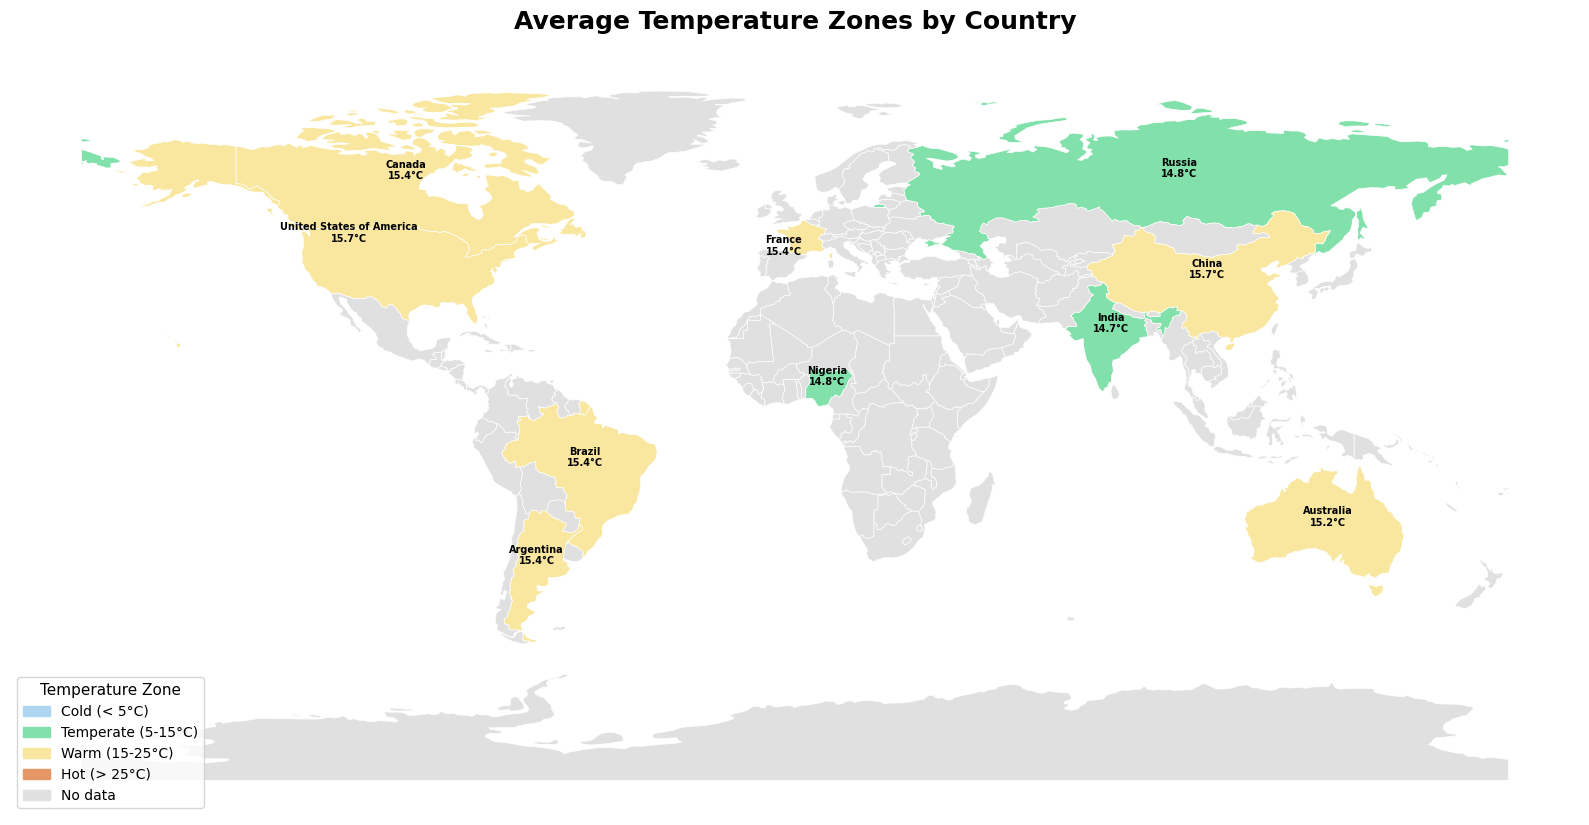

In [15]:
#temperature difference map
temp_zones = df.groupby("Country")["Average_Temperature_C"]\
    .mean()\
    .round(1)\
    .reset_index()\
    .rename(columns={"Average_Temperature_C": "avg_temp", "Country": "ADMIN"})

def temp_zone(t):
    if t < 5:       return "Cold (< 5°C)"
    elif t < 15:    return "Temperate (5-15°C)"
    elif t < 25:    return "Warm (15-25°C)"
    else:           return "Hot (> 25°C)"

temp_zones["zone"] = temp_zones["avg_temp"].apply(temp_zone)

world_temp = world.merge(temp_zones, on="ADMIN", how="left")

zone_colors = {
    "Cold (< 5°C)":         "#AED6F1",
    "Temperate (5-15°C)":   "#82E0AA",
    "Warm (15-25°C)":       "#F9E79F",
    "Hot (> 25°C)":         "#E59866"
}

world_temp["color"] = world_temp["zone"].map(zone_colors).fillna("#e0e0e0")

fig, ax = plt.subplots(figsize= (16, 9))
world_temp.plot(
    ax = ax,
    color = world_temp["color"],
    edgecolor="white",
    linewidth=0.5
)

legend_patches = [
    mpatches.Patch(color=color, label=zone)
    for zone, color in zone_colors.items()
]
legend_patches.append(mpatches.Patch(color="#e0e0e0", label="No data"))
ax.legend(handles=legend_patches, loc="lower left",
        fontsize=10, title="Temperature Zone", title_fontsize=11)

for idx, row in world_temp.dropna(subset=["zone"]).iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['ADMIN']}\n{row['avg_temp']:.1f}°C",
        xy = (centroid.x, centroid.y),
        ha = "center",
        fontsize = 7,
        fontweight = "bold"
    )

ax.set_title("Average Temperature Zones by Country",
            fontsize=18, fontweight="bold", pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/maps/03_temp_zones.png", dpi=150)
plt.show()

Writing datas to postgis and then reading it back

In [14]:
#writing datas to postgis and then reading it back
world_yield_clean = world_yield.dropna(subset=["avg_yield"]).copy()
world_econ_clean = world_econ.dropna(subset=["avg_econ"]).copy()

world_yield_clean.to_postgis("yield_by_country",
                            engine,
                            if_exists="replace",
                            index=False)

world_econ_clean.to_postgis("econ_by_country",
                            engine,
                            if_exists="replace",
                            index=False)

print(f" yield_by_country: {len(world_yield_clean)} rows")
print(f" econ_by_country: {len(world_econ_clean)} rows")

verify = gpd.read_postgis(
    'SELECT "ADMIN", avg_yield, geometry FROM yield_by_country ORDER BY avg_yield DESC',
    engine,
    geom_col="geometry"
)

print(f"\nTop 3 countries by yield from POSTGIS:")
print(verify[["ADMIN", "avg_yield"]].head(3))

 yield_by_country: 10 rows
 econ_by_country: 10 rows

Top 3 countries by yield from POSTGIS:
       ADMIN  avg_yield
0    Nigeria      2.279
1      China      2.260
2  Argentina      2.250
